# Giai đoạn 6 — Bảng huấn luyện hợp nhất

```
┌────────────────────────────────────────────────────────────────────────────────────────┐
│                                     06_TrainFinal                                      │
└────────────────────────────────────────────────────────────────────────────────────────┘

  ĐẦU VÀO
    • 01_LamSachKhaoSat/khaosat_sach.csv           —  676 phiếu THẬT
    • 05_KiemDinhDuLieuSinh/ttth_da_sinh.csv       —  16.296 dòng tổng hợp (bản đã chốt)
    • 05_KiemDinhDuLieuSinh/ket_luan.json          —  phương pháp nào thắng
         │
         ▼
  XỬ LÝ
    1. Dựng 63 đặc trưng cho CẢ HAI nguồn bằng CÙNG một hàm
    2. Gộp thành một bảng duy nhất
    3. Gắn cột quản lý: nguon · is_that · sample_weight
    4. Kiểm tra trùng lặp giữa hai nguồn
    5. Thống kê ô trống theo nguồn
         │
         ▼
  ĐẦU RA
    • 06_TrainFinal/train_final.csv                —  BẢNG DUY NHẤT, 16.972 dòng
    • 06_TrainFinal/thong_ke_dac_trung.csv
    • 06_TrainFinal/hinh_6_*.png                   —  3 hình
```

## Vì sao gộp trước rồi mới chia

Đây là yêu cầu về quy trình: **một bảng huấn luyện duy nhất**, rồi mới tách train/test
trên chính bảng đó. Mô hình học và được kiểm tra trên cùng một bộ dữ liệu đã hợp nhất,
không có nguồn nào được ưu ái hay bị giấu đi.

```
676 phiếu thật  ┐
                ├──▶  train_final.csv  ──▶  chia train/test  ──▶  học  ──▶  đo
16.296 dòng sinh┘        (Giai đoạn 6)        (Giai đoạn 7)      (9)      (10)
```

## Sáu mươi ba đặc trưng — MỘT hàm duy nhất cho cả hai nguồn

`dac_trung()` dùng chung. Nếu mỗi nguồn một hàm riêng thì hai bên sẽ trôi lệch, và lệch
một hằng số thì mô hình vẫn chạy, vẫn trả kết quả trông hợp lý, nhưng sai âm thầm.

| Nhóm | Số cột | Ghi chú |
|---|---:|---|
| Likert thô | 10 | |
| Likert chuẩn hoá theo người `ips_*` | 10 | **trừ trung bình, KHÔNG chia độ lệch** |
| Thống kê Likert | 2 | `likert_tb`, `likert_dolech` |
| Điểm thi thô | 10 | mỗi em chỉ 3 môn có điểm, 7 môn để **NaN** |
| Điểm z theo từng môn | 10 | 8.0 môn Toán ≠ 8.0 môn Văn |
| Phái sinh từ điểm | 4 | `diem_tb`, `diem_lech`, `z_tb`, `z_max` |
| Tổ hợp one-hot | 15 | tổ hợp là phân loại, **không có thứ tự** |
| Giới tính · mục tiêu | 2 | |

**Ô trống để NaN, không điền bừa.** XGBoost học luôn hướng rẽ cho giá trị thiếu ngay
trong thuật toán; điền bừa tạo ra giá trị không có thật mà mô hình lại tin là thật.

## Bốn cột quản lý

| Cột | Dùng làm gì |
|---|---|
| `nguon` | `khaosat` · `ttth` · `bootstrap_khaosat` |
| `is_that` | 1 nếu là phiếu người thật điền — **cột quan trọng nhất** |
| `sample_weight` | trọng số huấn luyện, Giai đoạn 9 quét |
| `ma_nganh` · `ma_nhom` | nhãn hai tầng |

`is_that` là cột phải có. Giai đoạn 10 sẽ báo cáo chỉ số **tách riêng dòng thật và dòng
tổng hợp** — không có cột này thì không tách được, và con số tổng gộp sẽ bị 96% dòng
tổng hợp chi phối.

## ⚠️ Bảng này có 96% dòng tổng hợp

676 dòng thật trên tổng 16.972 — tức **4,0%**. Ba hệ quả phải nêu trong báo cáo:

1. Chia ngẫu nhiên ở Giai đoạn 7 thì tập test cũng gồm ~96% dòng tổng hợp.
2. Mọi chỉ số tổng gộp đều phản ánh chủ yếu **chất lượng bộ sinh**, không phải khả năng
   dự đoán thí sinh thật.
3. Vì vậy Giai đoạn 10 bắt buộc phải có cột **"chỉ trên dòng thật"** — đó mới là con số
   trả lời được câu *"mô hình dự đoán thí sinh mới tốt tới đâu"*.


In [1]:
import json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle

warnings.filterwarnings("ignore")

PROC = Path("../data/processed")
RAW  = Path("../data/raw")
SEED = 42
np.random.seed(SEED)

# Web gửi limit=3 (web/src/app/(main)/predict/page.tsx) nên Top-3 là chỉ tiêu
# chính; Top-1/2/5 báo cáo kèm để thấy toàn cảnh.
TOP_K = (1, 2, 3, 5)

# Thư mục đầu ra trùng khít tên notebook
GIAI_DOAN = {
    1: "01_LamSachKhaoSat",
    2: "02_ChuanBiTTTH",
    3: "03_HocPhanPhoi",
    4: "04_SinhDacTrung",
    5: "05_KiemDinhDuLieuSinh",
    6: "06_TrainFinal",
    7: "07_TachTrainTest",
    8: "08_MocChuan",
    9: "09_TinhChinh",
    10: "10_ChotModel",
}


def thu_muc(i):
    """Thư mục đầu ra của giai đoạn i, tạo sẵn nếu chưa có."""
    p = PROC / GIAI_DOAN[i]
    p.mkdir(parents=True, exist_ok=True)
    return p


# ── Kiểu biểu đồ thống nhất cho toàn bộ báo cáo ──────────────────────────────
plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 220, "savefig.bbox": "tight",
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 14,
    "axes.labelsize": 11, "axes.labelpad": 8,
    "axes.grid": True, "grid.alpha": 0.18, "grid.linestyle": "-", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": False, "axes.edgecolor": "#B0B7BF",
    "figure.facecolor": "white", "axes.facecolor": "white",
    "legend.frameon": False, "legend.fontsize": 10,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "xtick.color": "#4A5560", "ytick.color": "#4A5560",
    "axes.labelcolor": "#2C3E50", "text.color": "#2C3E50",
})

C_THAT = "#D64550"   # dữ liệu thật
C_GA   = "#2BA84A"   # dữ liệu tổng hợp (GA)
C_XANH = "#3B7DD8"   # nhấn mạnh chính
C_CAM  = "#E8873A"   # nhấn mạnh phụ
C_TIM  = "#8E5FBF"
C_XAM  = "#AEB6BF"   # nền / mốc so sánh
C_DAM  = "#2C3E50"
C_NHOM = plt.get_cmap("tab20")(np.linspace(0, 1, 20))


def nhan_ngang(ax, gia_tri, fmt="{:,.0f}", lui=0.012, fs=10, mau=None):
    """Ghi số ở cuối mỗi thanh ngang."""
    lim = ax.get_xlim()[1]
    for i, v in enumerate(gia_tri):
        ax.text(v + lim * lui, i, fmt.format(v), va="center", fontsize=fs,
                fontweight="bold", color=mau or C_DAM)


def nhan_doc(ax, fmt="{:,.0f}", lui=0.02, fs=10):
    """Ghi số trên đầu mỗi cột dọc."""
    lim = ax.get_ylim()[1]
    for p in ax.patches:
        h = p.get_height()
        if h and abs(h) > 1e-9:
            ax.text(p.get_x() + p.get_width() / 2, h + lim * lui, fmt.format(h),
                    ha="center", va="bottom", fontsize=fs, fontweight="bold", color=C_DAM)


def chu_thich(fig, text, y=None):
    """Dòng chú giải dưới hình — nêu KẾT LUẬN rút ra, không mô tả lại hình.

    Chú giải (legend) đặt ngoài trục bằng bbox_to_anchor y âm có thể thò xuống
    dưới đáy hình; khi đó phải hạ dòng chú thích xuống dưới nó, nếu không hai bên
    đè lên nhau (bbox_inches="tight" nới khung chứ không dời chữ ra).
    """
    if y is None:
        y = -0.02
        fig.canvas.draw()
        r = fig.canvas.get_renderer()
        hop_ds = [lg.get_window_extent(r) for lg in fig.legends]
        hop_ds += [ax.get_legend().get_window_extent(r)
                   for ax in fig.axes if ax.get_legend() is not None]
        for hop in hop_ds:
            day = hop.transformed(fig.transFigure.inverted()).y0
            if day < y:
                y = day - 0.035
    fig.text(0.5, y, text, ha="center", va="top", fontsize=10.5,
             color="#5A6672", style="italic", wrap=True)


def ngat_dong(s, n=18):
    """Ngắt chuỗi dài thành nhiều dòng thay vì cắt cụt — nhãn vẫn đọc được hết."""
    tu, dong, cur = str(s).split(), [], ""
    for t in tu:
        if len(cur) + len(t) + 1 <= n or not cur:
            cur = f"{cur} {t}".strip()
        else:
            dong.append(cur); cur = t
    if cur:
        dong.append(cur)
    return "\n".join(dong)


def cho_chu_giai(ax, ngang=True, phan=0.28):
    """Nới trục để CHỪA CHỖ cho chú giải, tránh nó đè lên cột.

    Chú giải đặt trong vùng vẽ luôn có nguy cơ chồng lên dữ liệu. Cách chắc ăn
    là nới giới hạn trục thêm `phan` rồi đặt chú giải vào khoảng trống đó.
    """
    if ngang:
        lo, hi = ax.get_xlim(); ax.set_xlim(lo, hi + (hi - lo) * phan)
    else:
        lo, hi = ax.get_ylim(); ax.set_ylim(lo, hi + (hi - lo) * phan)


def cao_theo_dong(n, moi_dong=0.26, toi_thieu=4.5, toi_da=13):
    """Chiều cao hình cho biểu đồ cột ngang — 39 nhãn cần ~11 inch, không phải 7."""
    return float(np.clip(n * moi_dong + 2.0, toi_thieu, toi_da))


def luu(fig, ra, ten, chu=None):
    if chu:
        chu_thich(fig, chu)
    fig.savefig(ra / ten, dpi=220, bbox_inches="tight", facecolor="white")
    print(f"   💾 {ten}")


def tom_tat(tieu_de, dong_ds, rong=76):
    """Bảng tóm tắt cuối notebook — mỗi giai đoạn kết thúc bằng một cái."""
    print("╔" + "═" * rong + "╗")
    print("║" + f" {tieu_de} ".center(rong) + "║")
    print("╠" + "═" * rong + "╣")
    for d in dong_ds:
        print("║ " + str(d)[: rong - 2].ljust(rong - 1) + "║")
    print("╚" + "═" * rong + "╝")

def nap(co_test=False, co_ttth=True, co_fold=False):
    """Đọc mọi thứ notebook huấn luyện cần.

    Chia train/test diễn ra ở Giai đoạn 7,
    SAU khi bảng train final đã dựng xong. Nên:

        Giai đoạn 3–5   d["train"] = TOÀN BỘ 676 phiếu khảo sát, chưa có fold nào
        Giai đoạn 8–9   co_fold=True  → đọc train.csv và cv_folds.json của GĐ 7
        Giai đoạn 10    co_test=True  → mở tập test ĐÚNG MỘT LẦN

    Khoá "nhom" đọc từ `nganh_to_nhom` trong mapping.json — nguồn chuẩn duy nhất.
    """
    m = json.loads((thu_muc(1) / "mapping.json").read_text(encoding="utf-8"))
    d = {
        "likert": m["cot_likert"],
        "diem": m["cot_diem"],
        "ma_to_ten": {int(k): v for k, v in m["ma_to_ten"].items()},
        "nhom": {int(k): v for k, v in m["nganh_to_nhom"].items()},
        "ten_nhom": {int(k): v for k, v in m["ten_nhom"].items()},
        "ten_cach_nhom": m.get("ten_cach_nhom", "nhóm ngành"),
        "train": pd.read_csv(thu_muc(1) / "khaosat_sach.csv"),
    }
    d["ttth"] = pd.read_csv(thu_muc(2) / "ttth_sach.csv") if co_ttth else pd.DataFrame()
    if co_fold:
        d["train"] = pd.read_csv(thu_muc(7) / "train.csv")
        d["folds"] = json.loads((thu_muc(7) / "cv_folds.json").read_text(encoding="utf-8"))
    if co_test:
        d["test"] = pd.read_csv(thu_muc(7) / "test_KHOA.csv")

    nguon = [d["train"].to_hop_thi.str.split(" ").str[0]]
    if co_ttth:
        nguon.append(d["ttth"].to_hop_thi.astype(str))
    d["to_hop"] = sorted(set().union(*[set(s) for s in nguon]))
    d["nganh"] = np.sort(d["train"].ma_nganh.unique())
    d["i_nganh"] = {m_: i for i, m_ in enumerate(d["nganh"])}

    # Thống kê điểm để quy z-score. Tính trên TRAIN (+ TTTH nếu dùng), tuyệt đối
    # không đụng test — nếu không thì thông tin test rò rỉ qua bước chuẩn hoá.
    goc = [d["train"][d["diem"]]] + ([d["ttth"][d["diem"]]] if co_ttth else [])
    g = pd.concat(goc).astype(float)
    d["diem_mu"] = g.mean().values
    d["diem_sd"] = g.std().replace(0, 1).values
    return d


def dac_trung(df, D, co_khao_sat=True):
    """Ma trận 63 đặc trưng — MỘT định nghĩa duy nhất cho cả hai nguồn dữ liệu.

    `co_khao_sat=False` dùng cho hồ sơ trúng tuyển: nguồn này chỉ có điểm thi và
    tổ hợp. Cột thiếu để NaN chứ không điền bừa — XGBoost học luôn hướng rẽ cho
    giá trị thiếu ngay trong thuật toán, còn điền bừa tạo ra giá trị không có thật.
    """
    n = len(df)
    L, C_DIEM = D["likert"], D["diem"]
    th = df["to_hop_thi"].astype(str).str.split(" ").str[0].values
    Dm = df[C_DIEM].astype(float).values
    Lk = df[L].astype(float).values if co_khao_sat else np.full((n, len(L)), np.nan)

    ph = [pd.DataFrame(Lk, columns=L)]

    # Likert chuẩn hoá theo từng người: người hay chọn 4-5 và người hay chọn 2-3
    # cùng "thích logic nhất" nhưng để thô thì mô hình đọc thành hai hồ sơ khác
    # hẳn. Trừ trung bình của chính người đó thì còn lại sở thích TƯƠNG ĐỐI.
    with np.errstate(invalid="ignore"):
        mu = np.nanmean(Lk, 1, keepdims=True)
        sd = np.nanstd(Lk, 1, keepdims=True)
    sd = np.where((sd == 0) | np.isnan(sd), 1.0, sd)
    ph.append(pd.DataFrame(Lk - mu, columns=[f"ips_{c}" for c in L]))
    ph.append(pd.DataFrame({"likert_tb": mu[:, 0], "likert_dolech": sd[:, 0]}))

    ph.append(pd.DataFrame(Dm, columns=C_DIEM))
    # 8.0 môn Toán và 8.0 môn Văn không cùng ý nghĩa — quy z-score mới so được
    z = (Dm - D["diem_mu"]) / D["diem_sd"]
    ph.append(pd.DataFrame(z, columns=[f"z_{c}" for c in C_DIEM]))
    with np.errstate(invalid="ignore", divide="ignore"):
        ph.append(pd.DataFrame({
            "diem_tb": np.nanmean(Dm, 1),
            "diem_lech": np.nanmax(Dm, 1) - np.nanmin(Dm, 1),
            "z_tb": np.nanmean(z, 1),
            "z_max": np.nanmax(z, 1),
        }))

    # Tổ hợp là dữ liệu phân loại, KHÔNG có thứ tự. Mã hoá thành số (A00=0,
    # A01=1…) sẽ dạy mô hình rằng D01 "lớn hơn" A00 và trung bình A00 với B00 ra
    # A01 — vô nghĩa. One-hot tránh được: mỗi cột chỉ hỏi "có thi tổ hợp này không".
    ph.append(pd.DataFrame({f"th_{t}": (th == t).astype(float) for t in D["to_hop"]}))
    gt = ((df["gioi_tinh"] == "Nam").astype(float).values if "gioi_tinh" in df
          else np.full(n, np.nan))
    mt = (df["muc_tieu_ma"].astype(float).values if "muc_tieu_ma" in df
          else np.full(n, np.nan))
    ph.append(pd.DataFrame({"gioi_tinh_nam": gt, "muc_tieu": mt}))
    return pd.concat([p.reset_index(drop=True) for p in ph], axis=1)


def nhom_dac_trung(cols, D):
    """Gom tên cột thành 8 nhóm — dùng khi in bảng thống kê và vẽ hình."""
    L, C_DIEM = D["likert"], D["diem"]
    return {
        "Likert thô": [c for c in cols if c in L],
        "Likert chuẩn hoá theo người": [c for c in cols if c.startswith("ips_")],
        "Thống kê Likert": [c for c in cols if c in ("likert_tb", "likert_dolech")],
        "Điểm thi thô": [c for c in cols if c in C_DIEM],
        "Điểm z-score từng môn": [c for c in cols if c.startswith("z_diem_")],
        "Phái sinh từ điểm": [c for c in cols
                              if c in ("diem_tb", "diem_lech", "z_tb", "z_max")],
        "Tổ hợp xét tuyển (one-hot)": [c for c in cols if c.startswith("th_")],
        "Nhân khẩu học & mục tiêu": [c for c in cols
                                     if c in ("gioi_tinh_nam", "muc_tieu")],
    }

OUT = thu_muc(6)

D = nap(co_ttth=False)
ks = D["train"]
L, C_DIEM = D["likert"], D["diem"]

KL = json.loads((thu_muc(5) / "ket_luan.json").read_text(encoding="utf-8"))
sinh = pd.read_csv(thu_muc(5) / "ttth_da_sinh.csv")

print(f"Phiếu thật     : {len(ks):,} dòng")
print(f"Dòng tổng hợp  : {len(sinh):,} dòng")
print(f"   phương pháp : {KL['phuong_phap_chot']}")
print(f"   AUC phân biệt {KL['auc']:.3f} · sao chép {KL['sao_chep']:.1%}"
      f" · đa dạng {KL['da_dang']:.1%}")
print(f"\nTổng sẽ có     : {len(ks)+len(sinh):,} dòng"
      f"  ({100*len(sinh)/(len(ks)+len(sinh)):.1f}% tổng hợp)")

Phiếu thật     : 676 dòng
Dòng tổng hợp  : 16,296 dòng
   phương pháp : copula
   AUC phân biệt 0.583 · sao chép 0.6% · đa dạng 96.3%

Tổng sẽ có     : 16,972 dòng  (96.0% tổng hợp)


## 1. Thống nhất lược đồ hai nguồn

In [2]:
# `to_hop_thi` ở khảo sát có thể ghi nhiều tổ hợp cách nhau bằng dấu cách
# ("A00 A01 D01"), còn TTTH chỉ một. Lấy tổ hợp ĐẦU TIÊN cho cả hai để một hàm
# dac_trung() dùng được chung — nếu không, one-hot sẽ ra cột rác.
ks = ks.copy()
ks["to_hop_thi"] = ks.to_hop_thi.astype(str).str.split(" ").str[0]
ks["nguon"] = "khaosat"
ks["ma_nhom"] = ks.ma_nganh.map(D["nhom"])

can = ["ma_nganh", "ma_nhom", "to_hop_thi", "gioi_tinh", "muc_tieu_ma", "nguon"]
ks_g = ks[can + L + C_DIEM].copy()
sinh_g = sinh[can + L + C_DIEM].copy()

assert list(ks_g.columns) == list(sinh_g.columns), "hai nguồn lệch cột"
print(f"Lược đồ chung: {len(ks_g.columns)} cột")
print(f"   quản lý : {can}")
print(f"   Likert  : {len(L)} · điểm: {len(C_DIEM)}")

tho = pd.concat([ks_g, sinh_g], ignore_index=True)
tho["is_that"] = (tho.nguon == "khaosat").astype(int)
print(f"\nGộp thô: {len(tho):,} dòng")
print(tho.nguon.value_counts().to_string())

Lược đồ chung: 26 cột
   quản lý : ['ma_nganh', 'ma_nhom', 'to_hop_thi', 'gioi_tinh', 'muc_tieu_ma', 'nguon']
   Likert  : 10 · điểm: 10

Gộp thô: 16,972 dòng
nguon
ttth                 15696
khaosat                676
bootstrap_khaosat      600


## 2. Dựng 63 đặc trưng

In [3]:
# Thống kê điểm để quy z-score tính trên TOÀN BỘ bảng đã gộp — đúng tinh thần
# "một bảng duy nhất". Giai đoạn 7 mới chia, nên ở đây chưa có test để mà rò rỉ.
D["to_hop"] = sorted(tho.to_hop_thi.unique())
g = tho[C_DIEM].astype(float)
D["diem_mu"] = g.mean().values
D["diem_sd"] = g.std().replace(0, 1).values

X = dac_trung(tho, D, co_khao_sat=True)
print(f"Ma trận đặc trưng: {X.shape[0]:,} dòng × {X.shape[1]} cột")

nhom_ct = nhom_dac_trung(list(X.columns), D)
for ten, cot in nhom_ct.items():
    print(f"   {ten:<28} {len(cot):>3} cột")
assert X.shape[1] == 63, f"phải đúng 63 đặc trưng, đang có {X.shape[1]}"

tf = pd.concat([X, tho[["ma_nganh", "ma_nhom", "nguon", "is_that"]]], axis=1)
# Trọng số mặc định 1.0 — Giai đoạn 9 quét xem có nên nâng trọng số dòng thật
tf["sample_weight"] = 1.0
tf.to_csv(OUT / "train_final.csv", index=False)

print(f"\ntrain_final.csv: {len(tf):,} dòng × {len(tf.columns)} cột")
print(f"   63 đặc trưng + {len(tf.columns)-63} cột quản lý")

Ma trận đặc trưng: 16,972 dòng × 63 cột
   Likert thô                    10 cột
   Likert chuẩn hoá theo người   10 cột
   Thống kê Likert                2 cột
   Điểm thi thô                  10 cột
   Điểm z-score từng môn         10 cột
   Phái sinh từ điểm              4 cột
   Tổ hợp xét tuyển (one-hot)    15 cột
   Nhân khẩu học & mục tiêu       2 cột



train_final.csv: 16,972 dòng × 68 cột
   63 đặc trưng + 5 cột quản lý


## 3. Kiểm tra trùng lặp giữa hai nguồn

In [4]:
# Bản sao của một phiếu thật nằm trong phần tổng hợp là nguồn RÒ RỈ trực tiếp:
# Giai đoạn 7 chia ngẫu nhiên, nên phiếu thật có thể rơi vào test trong khi bản
# sao của nó nằm ở train. Giai đoạn 5 đã ràng buộc < 5%, kiểm lại ở đây trên
# bảng cuối cùng cho chắc.
bo_that = set(map(tuple, ks_g[L].to_numpy(int)))
trung = [tuple(r) in bo_that for r in sinh_g[L].to_numpy(int)]
n_trung = int(np.sum(trung))

print(f"Dòng tổng hợp trùng KHÍT một phiếu thật: {n_trung:,}/{len(sinh_g):,}"
      f"  ({100*n_trung/len(sinh_g):.2f}%)")
print(f"Ngưỡng đã đặt ở Giai đoạn 5           : {KL['nguong_sao_chep']:.0%}")
assert n_trung / len(sinh_g) < KL["nguong_sao_chep"], "vượt ngưỡng sao chép"

# Trùng trong nội bộ phần tổng hợp thì không phải rò rỉ, nhưng nhiều quá thì
# mô hình học đi học lại cùng một mẫu.
dd = len(sinh_g[L].drop_duplicates()) / len(sinh_g)
print(f"\nĐa dạng phần tổng hợp: {dd:.1%}"
      f"   (phiếu thật {len(ks_g[L].drop_duplicates())/len(ks_g):.1%})")

print(f"\nPhân bố nhãn:")
print(f"   ngành : {tf.ma_nganh.nunique()}/39 · ít nhất {tf.ma_nganh.value_counts().min():,}"
      f" · nhiều nhất {tf.ma_nganh.value_counts().max():,} dòng")
print(f"   nhóm  : {tf.ma_nhom.nunique()}/9")
assert tf.ma_nganh.nunique() == 39, "có ngành biến mất khỏi bảng"

Dòng tổng hợp trùng KHÍT một phiếu thật: 96/16,296  (0.59%)
Ngưỡng đã đặt ở Giai đoạn 5           : 5%

Đa dạng phần tổng hợp: 96.3%   (phiếu thật 97.6%)

Phân bố nhãn:
   ngành : 39/39 · ít nhất 36 · nhiều nhất 1,879 dòng
   nhóm  : 9/9


   💾 hinh_6_1_cau_tao.png


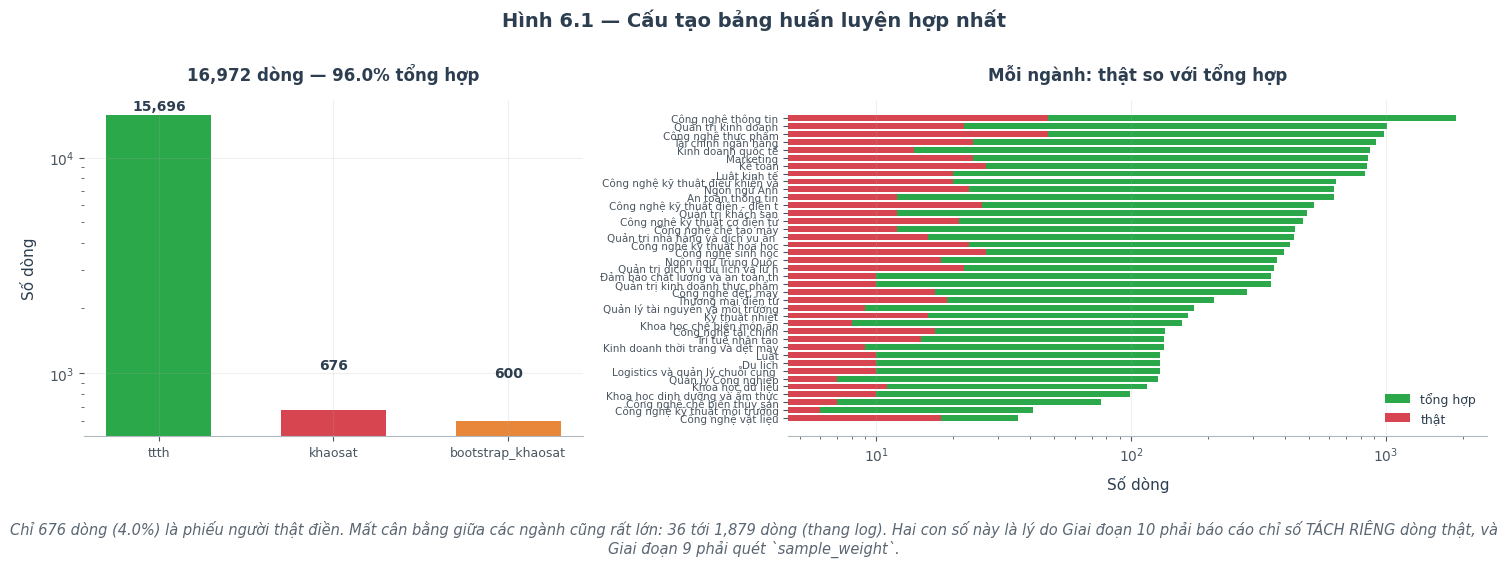

In [5]:
# ═══════════ HÌNH 6.1 — Cấu tạo bảng train final ═══════════
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 5),
                             gridspec_kw={"width_ratios": [1, 1.4]})
vc = tf.nguon.value_counts()
mau_ng = {"khaosat": C_THAT, "ttth": C_GA, "bootstrap_khaosat": C_CAM}
a1.bar(range(len(vc)), vc.values, color=[mau_ng[n] for n in vc.index], width=.6)
a1.set_xticks(range(len(vc)))
a1.set_xticklabels([ngat_dong(n, 12) for n in vc.index], fontsize=9)
nhan_doc(a1, fmt="{:,.0f}")
a1.set_ylabel("Số dòng"); a1.set_yscale("log")
a1.set_title(f"{len(tf):,} dòng — {100*(1-tf.is_that.mean()):.1f}% tổng hợp", fontsize=12)

sl = tf.groupby("ma_nganh").agg(tong=("is_that", "size"), that=("is_that", "sum"))
sl["ten"] = [D["ma_to_ten"][m][:32] for m in sl.index]
sl = sl.sort_values("tong")
yy = np.arange(len(sl))
a2.barh(yy, sl.tong, color=C_GA, height=.74, label="tổng hợp")
a2.barh(yy, sl.that, color=C_THAT, height=.74, label="thật")
a2.set_yticks(yy); a2.set_yticklabels(sl.ten, fontsize=7.5)
a2.set_xlabel("Số dòng"); a2.set_xscale("log"); a2.grid(axis="y", alpha=0)
a2.legend(fontsize=9, loc="lower right")
a2.set_title("Mỗi ngành: thật so với tổng hợp", fontsize=12)

fig.suptitle("Hình 6.1 — Cấu tạo bảng huấn luyện hợp nhất",
             fontsize=14, fontweight="bold", y=1.0)
fig.tight_layout()
luu(fig, OUT, "hinh_6_1_cau_tao.png",
    f"Chỉ {tf.is_that.sum()} dòng ({100*tf.is_that.mean():.1f}%) là phiếu người thật "
    f"điền. Mất cân bằng giữa các ngành cũng rất lớn: {sl.tong.min():,} tới "
    f"{sl.tong.max():,} dòng (thang log). Hai con số này là lý do Giai đoạn 10 phải "
    f"báo cáo chỉ số TÁCH RIÊNG dòng thật, và Giai đoạn 9 phải quét `sample_weight`.")
plt.show()

   💾 hinh_6_2_o_trong.png


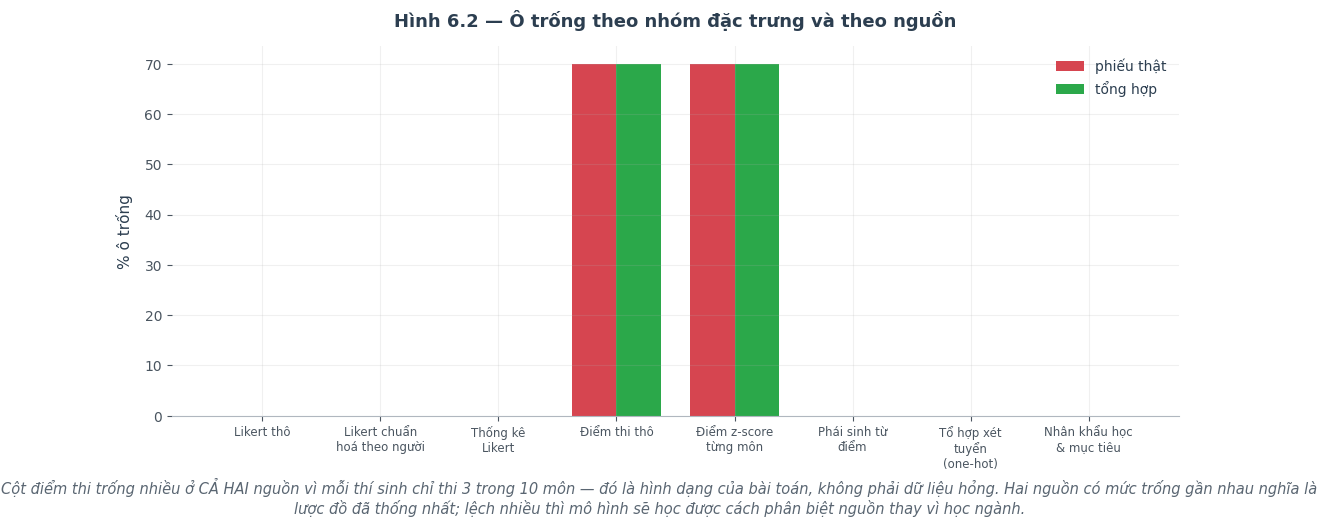

In [6]:
# ═══════════ HÌNH 6.2 — Ô trống theo nhóm đặc trưng ═══════════
tk = []
for ten, cot in nhom_ct.items():
    for ng in ["khaosat", "ttth"]:
        m = tf.nguon == ng
        tk.append({"nhom": ten, "nguon": ng,
                   "trong": float(X.loc[m.values, cot].isna().mean().mean() * 100)})
tk = pd.DataFrame(tk)
tk.to_csv(OUT / "thong_ke_dac_trung.csv", index=False)

fig, ax = plt.subplots(figsize=(13, 4.8))
nhoms = list(nhom_ct)
x = np.arange(len(nhoms)); w_ = .38
for j, (ng, mau_) in enumerate([("khaosat", C_THAT), ("ttth", C_GA)]):
    v = [tk[(tk.nhom == n) & (tk.nguon == ng)].trong.iloc[0] for n in nhoms]
    ax.bar(x + (j - .5) * w_, v, w_, color=mau_,
           label="phiếu thật" if ng == "khaosat" else "tổng hợp")
ax.set_xticks(x)
ax.set_xticklabels([ngat_dong(n, 14) for n in nhoms], fontsize=8.5)
ax.set_ylabel("% ô trống"); ax.legend(fontsize=10)
ax.set_title("Hình 6.2 — Ô trống theo nhóm đặc trưng và theo nguồn")
luu(fig, OUT, "hinh_6_2_o_trong.png",
    f"Cột điểm thi trống nhiều ở CẢ HAI nguồn vì mỗi thí sinh chỉ thi 3 trong 10 môn — "
    f"đó là hình dạng của bài toán, không phải dữ liệu hỏng. Hai nguồn có mức trống gần "
    f"nhau nghĩa là lược đồ đã thống nhất; lệch nhiều thì mô hình sẽ học được cách phân "
    f"biệt nguồn thay vì học ngành.")
plt.show()

   💾 hinh_6_3_chong_lap.png


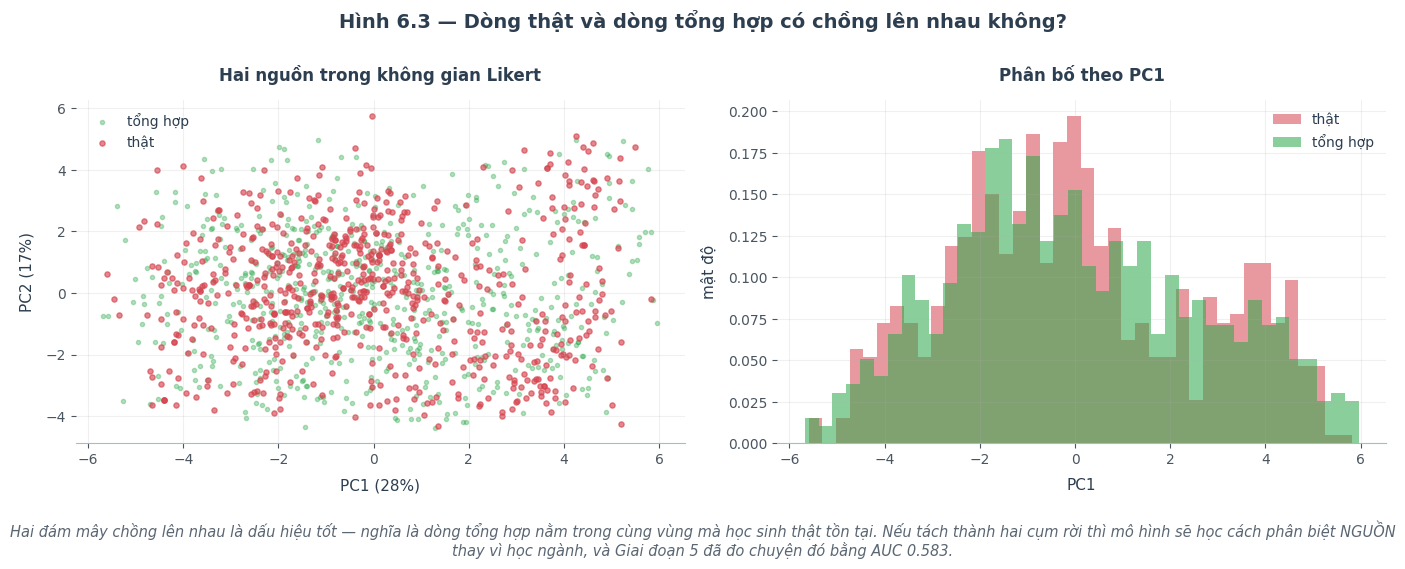

In [7]:
# ═══════════ HÌNH 6.3 — Hai nguồn có chồng lên nhau không ═══════════
# Nếu dòng thật và dòng tổng hợp nằm ở hai vùng tách biệt thì mô hình sẽ học
# cách phân biệt NGUỒN chứ không học ngành. Chiếu xuống 2 chiều để nhìn.
from sklearn.decomposition import PCA

cot_lk = nhom_ct["Likert thô"] + nhom_ct["Likert chuẩn hoá theo người"]
M = X[cot_lk].fillna(X[cot_lk].mean()).values
rng = np.random.default_rng(SEED)
i_that = np.where(tf.is_that.values == 1)[0]
i_gia = rng.choice(np.where(tf.is_that.values == 0)[0], len(i_that), replace=False)
P = PCA(n_components=2, random_state=SEED).fit(M[np.r_[i_that, i_gia]])

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
Zt, Zg = P.transform(M[i_that]), P.transform(M[i_gia])
a1.scatter(Zg[:, 0], Zg[:, 1], s=9, color=C_GA, alpha=.35, label="tổng hợp")
a1.scatter(Zt[:, 0], Zt[:, 1], s=14, color=C_THAT, alpha=.65, label="thật")
a1.set_xlabel(f"PC1 ({P.explained_variance_ratio_[0]:.0%})")
a1.set_ylabel(f"PC2 ({P.explained_variance_ratio_[1]:.0%})")
a1.legend(fontsize=10); a1.set_title("Hai nguồn trong không gian Likert", fontsize=12)

for ax_, Zx, ten_, mau_ in [(a2, Zt, "thật", C_THAT), (a2, Zg, "tổng hợp", C_GA)]:
    ax_.hist(Zx[:, 0], bins=40, alpha=.55, color=mau_, label=ten_, density=True)
a2.set_xlabel("PC1"); a2.set_ylabel("mật độ"); a2.legend(fontsize=10)
a2.set_title("Phân bố theo PC1", fontsize=12)

fig.suptitle("Hình 6.3 — Dòng thật và dòng tổng hợp có chồng lên nhau không?",
             fontsize=14, fontweight="bold", y=1.0)
fig.tight_layout()
luu(fig, OUT, "hinh_6_3_chong_lap.png",
    f"Hai đám mây chồng lên nhau là dấu hiệu tốt — nghĩa là dòng tổng hợp nằm trong cùng "
    f"vùng mà học sinh thật tồn tại. Nếu tách thành hai cụm rời thì mô hình sẽ học cách "
    f"phân biệt NGUỒN thay vì học ngành, và Giai đoạn 5 đã đo chuyện đó bằng AUC "
    f"{KL['auc']:.3f}.")
plt.show()

## 4. Tóm tắt

In [8]:
(OUT / "tom_tat.json").write_text(json.dumps({
    "n_dong": int(len(tf)),
    "n_that": int(tf.is_that.sum()),
    "n_tong_hop": int((1 - tf.is_that).sum()),
    "ti_le_tong_hop": round(float(1 - tf.is_that.mean()), 4),
    "n_dac_trung": 63,
    "n_nganh": int(tf.ma_nganh.nunique()),
    "n_nhom": int(tf.ma_nhom.nunique()),
    "phuong_phap_sinh": KL["phuong_phap_chot"],
    "trung_khit_phieu_that": round(n_trung / len(sinh_g), 4),
    "da_dang_tong_hop": round(dd, 4),
    "dong_moi_nganh_min": int(tf.ma_nganh.value_counts().min()),
    "dong_moi_nganh_max": int(tf.ma_nganh.value_counts().max()),
}, ensure_ascii=False, indent=2), encoding="utf-8")

tom_tat("GIAI ĐOẠN 6 — BẢNG HUẤN LUYỆN HỢP NHẤT", [
    f"train_final.csv        {len(tf):,} dòng × 63 đặc trưng",
    "",
    f"   phiếu thật          {int(tf.is_that.sum()):,}"
    f"   ({100*tf.is_that.mean():.1f}%)",
    f"   tổng hợp            {int((1-tf.is_that).sum()):,}"
    f"   ({100*(1-tf.is_that.mean()):.1f}%)",
    f"   phương pháp sinh    {KL['phuong_phap_chot']}",
    "",
    f"Nhãn                   {tf.ma_nganh.nunique()} ngành · {tf.ma_nhom.nunique()} nhóm",
    f"Dòng mỗi ngành         {tf.ma_nganh.value_counts().min():,}"
    f" … {tf.ma_nganh.value_counts().max():,}"
    f"  (chênh {tf.ma_nganh.value_counts().max()//tf.ma_nganh.value_counts().min()}×)",
    "",
    f"Trùng khít phiếu thật  {n_trung:,} dòng ({100*n_trung/len(sinh_g):.2f}%)  ✓",
    f"Đa dạng tổng hợp       {dd:.1%}",
    "",
    "⚠️  96% dòng là tổng hợp — Giai đoạn 10 PHẢI tách riêng chỉ số dòng thật",
])
print(f"\n✅ train_final.csv · thong_ke_dac_trung.csv · 3 hình  →  {OUT}")

╔════════════════════════════════════════════════════════════════════════════╗
║                   GIAI ĐOẠN 6 — BẢNG HUẤN LUYỆN HỢP NHẤT                   ║
╠════════════════════════════════════════════════════════════════════════════╣
║ train_final.csv        16,972 dòng × 63 đặc trưng                          ║
║                                                                            ║
║    phiếu thật          676   (4.0%)                                        ║
║    tổng hợp            16,296   (96.0%)                                    ║
║    phương pháp sinh    copula                                              ║
║                                                                            ║
║ Nhãn                   39 ngành · 9 nhóm                                   ║
║ Dòng mỗi ngành         36 … 1,879  (chênh 52×)                             ║
║                                                                            ║
║ Trùng khít phiếu thật  96 dòng (0.59%)  ✓         